# Анализ сайта СберАвтоподписка

Задача: предсказать, совершит ли пользователь целевое действие (заявку, звонок, диалог) во время визита на sberauto.com. Метрика — ROC-AUC, ориентир по заданию ≥ 0.65.

Признаки считаются по тому, что есть на момент начала сессии: utm, geo, device, время, история клиента из прошлых сессий.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
import shap
import joblib
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')


## 1. Загрузка и первичный осмотр данных

In [2]:
print('Загружаем sessions...')
sessions = pd.read_pickle('DATA/ga_sessions.pkl')
print(f'  sessions: {sessions.shape}')

print('Загружаем hits...')
hits = pd.read_pickle('DATA/ga_hits.pkl')
print(f'  hits:     {hits.shape}')


Загружаем sessions...
  sessions: (1860042, 18)
Загружаем hits...
  hits:     (15726470, 11)


In [3]:
print('sessions head:')
display(sessions.head(3))
print('hits head:')
display(hits.head(3))


sessions head:


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


hits head:


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None


In [4]:
# типы и пропуски по sessions
miss_s = pd.DataFrame({
    'dtype': sessions.dtypes,
    'null%': (sessions.isnull().mean() * 100).round(2)
})
display(miss_s)


,dtype,null%
session_id,object,0.00
client_id,object,0.00
visit_date,object,0.00
visit_time,object,0.00
visit_number,int64,0.00
utm_source,object,0.01
utm_medium,object,0.00
utm_campaign,object,11.81
utm_adcontent,object,18.04
utm_keyword,object,58.17


In [5]:
# типы и пропуски по hits
miss_h = pd.DataFrame({
    'dtype': hits.dtypes,
    'null%': (hits.isnull().mean() * 100).round(2)
})
display(miss_h)


,dtype,null%
session_id,object,0.00
hit_date,object,0.00
hit_time,float64,58.25
hit_number,int64,0.00
hit_type,object,0.00
hit_referer,object,39.90
hit_page_path,object,0.00
event_category,object,0.00
event_action,object,0.00
event_label,object,23.91


**Что видно:**
- В `sessions` много пропусков в `utm_campaign`, `utm_adcontent`, `utm_keyword` — органический трафик такие поля не отдаёт
- В `device_model`, `device_brand`, `device_os` пропуски зависят от user-agent браузера
- В `hits` поля `event_*` заполнены только для хитов-событий, для обычных pageview они пустые — это нормально


## 2. Чистка данных

In [6]:
# проверяем дубликаты в sessions
n_dup_full = sessions.duplicated().sum()
n_dup_sid = sessions['session_id'].duplicated().sum()
print(f'Полных дублей строк в sessions: {n_dup_full}')
print(f'Дублей по session_id:           {n_dup_sid}')

if n_dup_sid > 0:
    sessions = sessions.drop_duplicates(subset='session_id', keep='first')
    print(f'После dedup: {sessions.shape}')


Полных дублей строк в sessions: 0
Дублей по session_id:           0


In [7]:
# в hits дубли событий по связке (session_id, hit_number, event_action) лишние
n_dup_h = hits.duplicated(subset=['session_id', 'hit_number', 'event_action']).sum()
print(f'Дублей в hits по (session_id, hit_number, event_action): {n_dup_h}')

if n_dup_h > 0:
    hits = hits.drop_duplicates(subset=['session_id', 'hit_number', 'event_action'])
    print(f'После dedup: {hits.shape}')


Дублей в hits по (session_id, hit_number, event_action): 225862
После dedup: (15500608, 11)


## 3. Формирование целевой переменной

По глоссарию целевое действие — оставить заявку, заказать звонок, открыть диалог и др.
Отбор по ключевым словам в `event_action`: `claim`, `callback`, `call`, `dialog`, `submit_success`, `start_chat`.

In [8]:
# смотрим топ значений event_action, чтобы выбрать целевые
top_events = hits['event_action'].value_counts().head(30)
display(top_events)


event_action
view_card                             3481715
view_new_card                         3473918
sub_landing                           1779695
go_to_car_card                         962624
sub_view_cars_click                    784141
search_form_region                     508891
search_form_search_btn                 431103
sap_search_form_cost_to                355157
showed_number_ads                      326274
pagination_click                       248932
search_form_mark_select                220984
quiz_show                              211021
search_form_model_select               210517
sap_search_form_cost_from              187536
photos_all                             179470
search_form_search_car_type_select     173733
photos                                 156134
sub_car_page                           130299
view_more_click                        109961
search_kpp                              78957
sub_header_link_click                   77717
proactive invitation 

In [9]:
# отбираем целевые действия по содержимому строки event_action
pattern = re.compile(r'(claim|callback|call_number|open_dialog|submit_success|start_chat)', re.I)

all_events = hits['event_action'].dropna().unique()
TARGET_EVENTS = sorted([e for e in all_events if pattern.search(str(e))])

print(f'Найдено целевых event_action: {len(TARGET_EVENTS)}')
for e in TARGET_EVENTS:
    print(' ', e)


Найдено целевых event_action: 14
  callback button
  callback requested
  click_on_start_chatting
  greenday_sub_call_number_click
  greenday_sub_callback_submit_click
  greenday_sub_open_dialog_click
  greenday_sub_submit_success
  start_chat
  sub_call_number_click
  sub_callback_submit_click
  sub_car_claim_click
  sub_car_claim_submit_click
  sub_open_dialog_click
  sub_submit_success


In [10]:
# флаг: была ли хоть одна целевая активность в сессии
hits['is_target'] = hits['event_action'].isin(TARGET_EVENTS).astype(int)
target_df = (
    hits.groupby('session_id')['is_target']
    .max()
    .reset_index()
    .rename(columns={'is_target': 'target'})
)

print(target_df['target'].value_counts())
print(f'CR = {target_df["target"].mean():.4%}')


target
0    1656114
1      78496
Name: count, dtype: int64
CR = 4.5253%


In [11]:
# объединяем sessions с таргетом; сессии без хитов считаем нецелевыми
df = sessions.merge(target_df, on='session_id', how='left')
df['target'] = df['target'].fillna(0).astype(int)

print(f'Итоговый датасет: {df.shape}')
print(f'CR = {df["target"].mean():.4%}')


Итоговый датасет: (1860042, 19)
CR = 4.1943%


## 4. Разведочный анализ (EDA)

### 4.1 Баланс классов

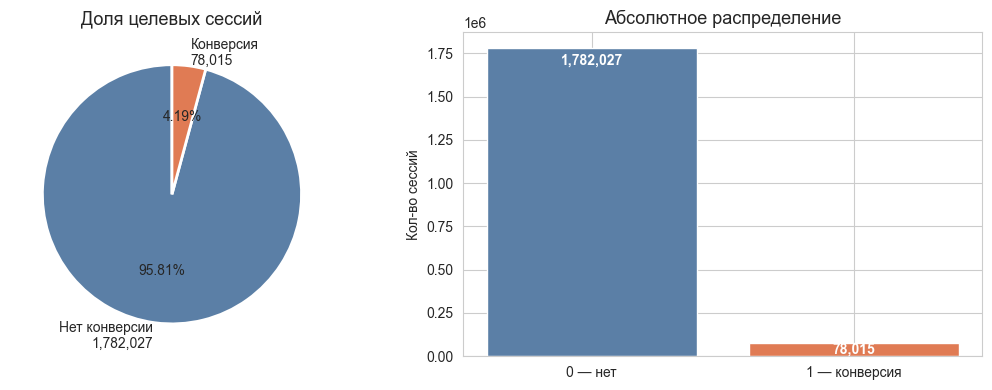

Дисбаланс примерно 1:23


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['target'].value_counts()
labels = [f'Нет конверсии\n{counts[0]:,}', f'Конверсия\n{counts[1]:,}']
axes[0].pie(counts, labels=labels, autopct='%1.2f%%',
            colors=['#5B7FA6', '#E07B54'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Доля целевых сессий')

axes[1].bar(['0 — нет', '1 — конверсия'], counts.values,
            color=['#5B7FA6', '#E07B54'], edgecolor='white')
axes[1].set_ylabel('Кол-во сессий')
axes[1].set_title('Абсолютное распределение')
for i, v in enumerate(counts.values):
    axes[1].text(i, v * 0.98, f'{v:,}', ha='center', va='top', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('img_class_balance.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Дисбаланс примерно 1:{round(counts[0]/counts[1])}')


### 4.2 Конверсия по каналам трафика

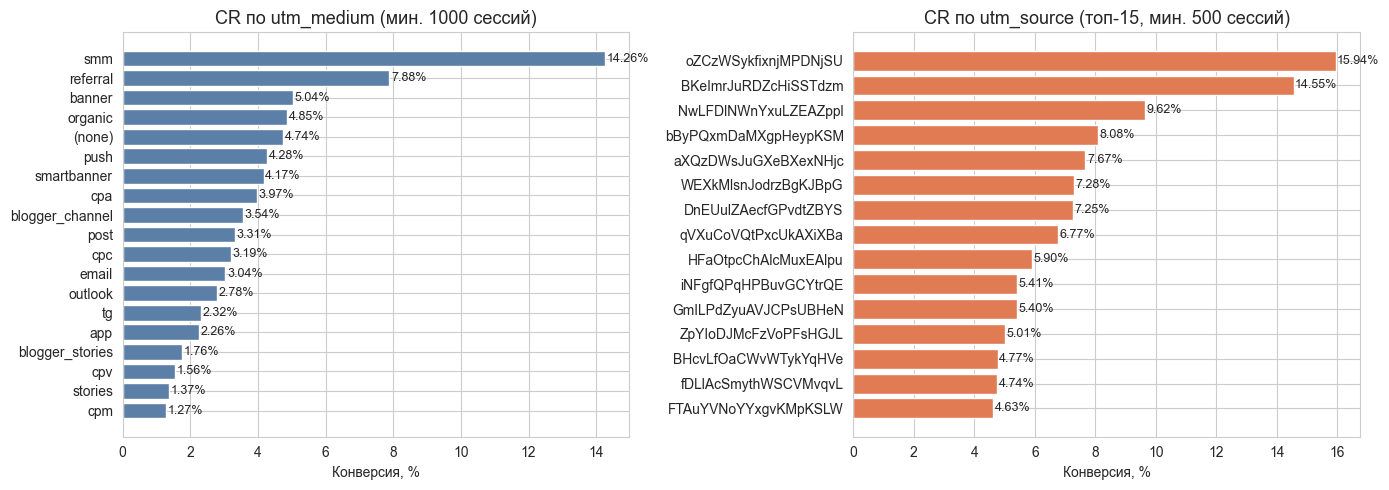

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cr_medium = df.groupby('utm_medium')['target'].agg(['mean', 'count']).reset_index()
cr_medium = cr_medium[cr_medium['count'] >= 1000].sort_values('mean', ascending=True)
axes[0].barh(cr_medium['utm_medium'], cr_medium['mean'] * 100, color='#5B7FA6')
axes[0].set_xlabel('Конверсия, %')
axes[0].set_title('CR по utm_medium (мин. 1000 сессий)')
for i, (_, row) in enumerate(cr_medium.iterrows()):
    axes[0].text(row['mean'] * 100 + 0.05, i, f'{row["mean"]:.2%}', va='center', fontsize=9)

cr_source = df.groupby('utm_source')['target'].agg(['mean', 'count']).reset_index()
cr_source = cr_source[cr_source['count'] >= 500].nlargest(15, 'mean').sort_values('mean', ascending=True)
axes[1].barh(cr_source['utm_source'], cr_source['mean'] * 100, color='#E07B54')
axes[1].set_xlabel('Конверсия, %')
axes[1].set_title('CR по utm_source (топ-15, мин. 500 сессий)')
for i, (_, row) in enumerate(cr_source.iterrows()):
    axes[1].text(row['mean'] * 100 + 0.05, i, f'{row["mean"]:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('img_cr_traffic.png', dpi=100, bbox_inches='tight')
plt.show()


CR заметно отличается по каналам: платный трафик (`cpc`) выше, чем органика. `utm_medium` и `utm_source` идут в признаки.

### 4.3 Конверсия по устройствам

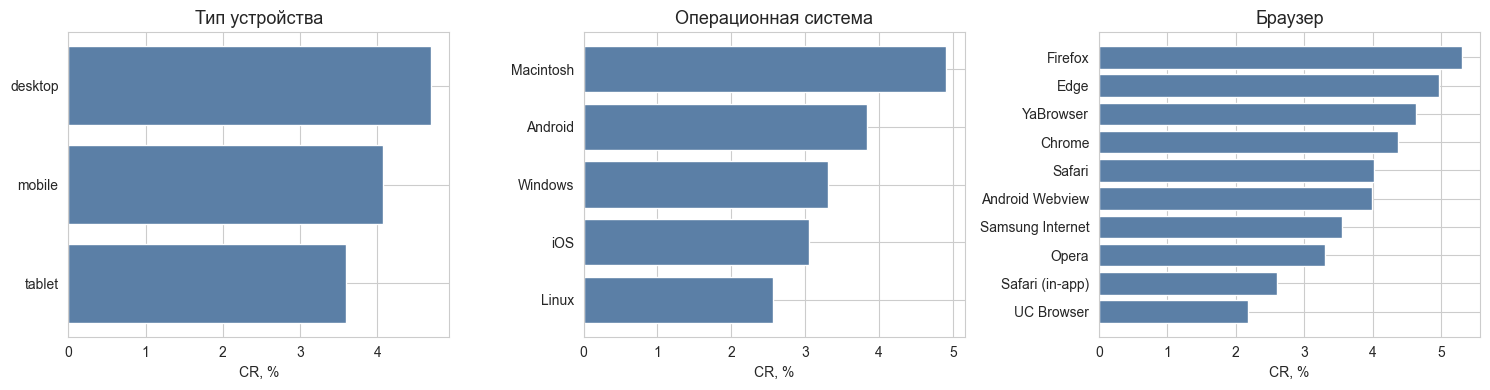

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['device_category', 'device_os', 'device_browser'],
    ['Тип устройства', 'Операционная система', 'Браузер']
):
    cr = df.groupby(col)['target'].agg(['mean', 'count']).reset_index()
    cr = cr[cr['count'] >= 500].nlargest(10, 'count').sort_values('mean', ascending=True)
    ax.barh(cr[col].astype(str), cr['mean'] * 100, color='#5B7FA6')
    ax.set_xlabel('CR, %')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('img_cr_device.png', dpi=100, bbox_inches='tight')
plt.show()


### 4.4 Конверсия по времени визита

Не удалось распарсить datetime: 0 (0.0000%)


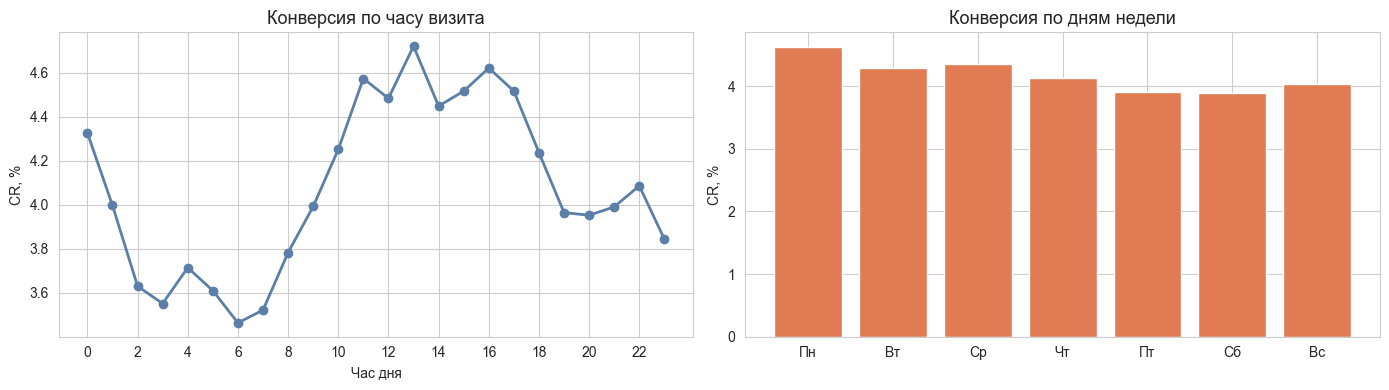

In [15]:
# собираем datetime из visit_date и visit_time
df['visit_dt'] = pd.to_datetime(
    df['visit_date'].astype(str) + ' ' + df['visit_time'].astype(str),
    errors='coerce'
)
n_bad = df['visit_dt'].isna().sum()
print(f'Не удалось распарсить datetime: {n_bad} ({n_bad / len(df):.4%})')

df['visit_hour'] = df['visit_dt'].dt.hour
df['visit_dayofweek'] = df['visit_dt'].dt.dayofweek
df['visit_month'] = df['visit_dt'].dt.month
df['is_weekend'] = (df['visit_dayofweek'] >= 5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cr_hour = df.groupby('visit_hour')['target'].mean()
axes[0].plot(cr_hour.index, cr_hour.values * 100, marker='o', color='#5B7FA6', linewidth=2)
axes[0].set_xlabel('Час дня')
axes[0].set_ylabel('CR, %')
axes[0].set_title('Конверсия по часу визита')
axes[0].set_xticks(range(0, 24, 2))

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
cr_dow = df.groupby('visit_dayofweek')['target'].mean()
axes[1].bar(day_names, cr_dow.values * 100, color='#E07B54')
axes[1].set_ylabel('CR, %')
axes[1].set_title('Конверсия по дням недели')

plt.tight_layout()
plt.savefig('img_cr_time.png', dpi=100, bbox_inches='tight')
plt.show()


Конверсия выше в рабочие часы (10–19) и в будни.

### 4.5 Конверсия по топ-20 городам

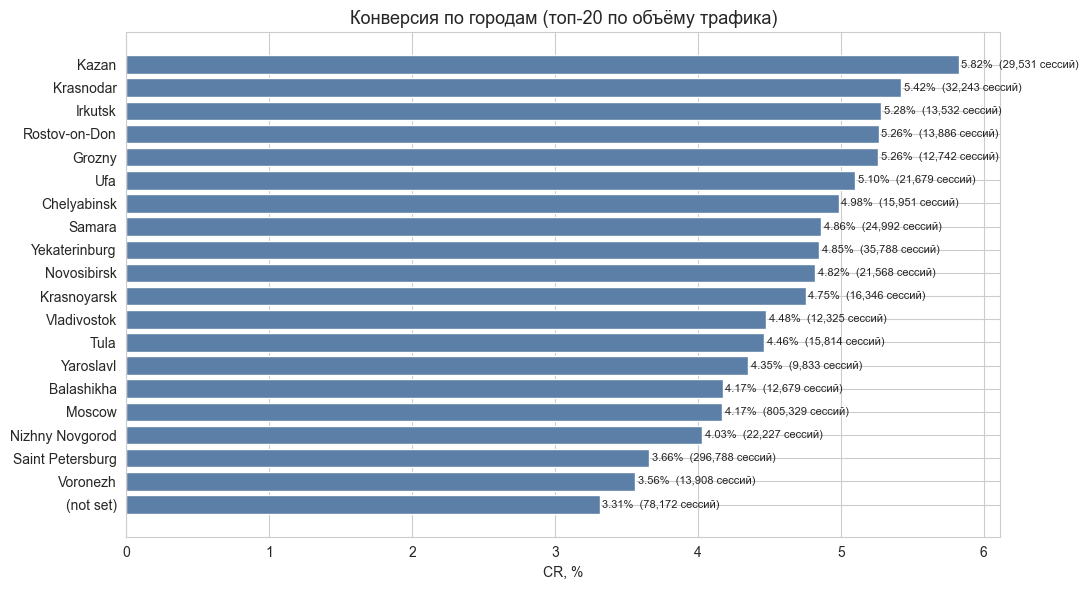

In [16]:
cr_city = df.groupby('geo_city')['target'].agg(['mean', 'count']).reset_index()
cr_city = cr_city[cr_city['count'] >= 500].nlargest(20, 'count').sort_values('mean', ascending=True)

plt.figure(figsize=(11, 6))
bars = plt.barh(cr_city['geo_city'], cr_city['mean'] * 100, color='#5B7FA6')
plt.xlabel('CR, %')
plt.title('Конверсия по городам (топ-20 по объёму трафика)')
for bar, (_, row) in zip(bars, cr_city.iterrows()):
    plt.text(row['mean'] * 100 + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{row["mean"]:.2%}  ({row["count"]:,} сессий)',
             va='center', fontsize=8)
plt.tight_layout()
plt.savefig('img_cr_city.png', dpi=100, bbox_inches='tight')
plt.show()


### 4.6 visit_number — порядковый номер визита клиента

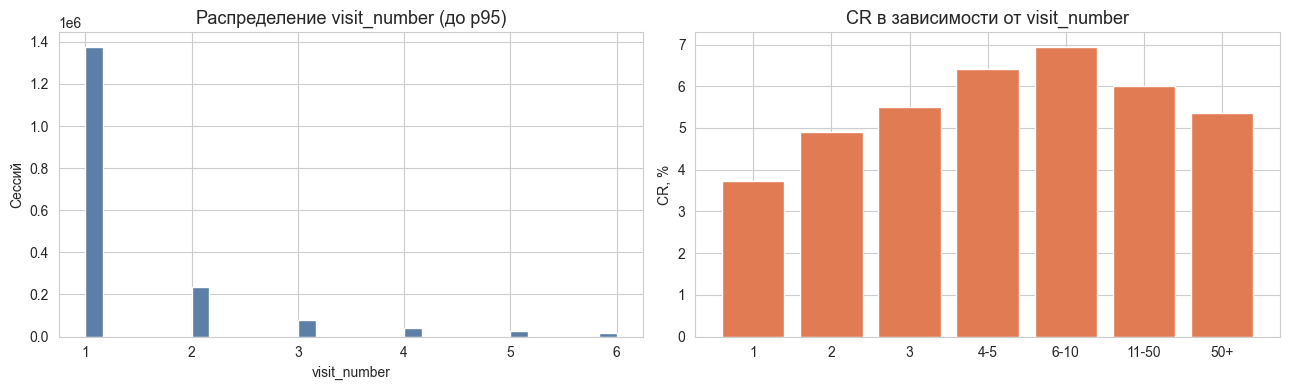

In [17]:
# распределение до 95-го перцентиля
p95 = df['visit_number'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df.loc[df['visit_number'] <= p95, 'visit_number'], bins=30, color='#5B7FA6', edgecolor='white')
axes[0].set_xlabel('visit_number')
axes[0].set_ylabel('Сессий')
axes[0].set_title('Распределение visit_number (до p95)')

# CR по бинам visit_number
df['vn_bin'] = pd.cut(df['visit_number'], bins=[0,1,2,3,5,10,50,100000], right=True,
                      labels=['1','2','3','4-5','6-10','11-50','50+'])
cr_vn = df.groupby('vn_bin', observed=True)['target'].mean()
axes[1].bar(range(len(cr_vn)), cr_vn.values * 100, color='#E07B54')
axes[1].set_xticks(range(len(cr_vn)))
axes[1].set_xticklabels(cr_vn.index)
axes[1].set_ylabel('CR, %')
axes[1].set_title('CR в зависимости от visit_number')

plt.tight_layout()
plt.savefig('img_hits_depth.png', dpi=100, bbox_inches='tight')
plt.show()


Повторные визиты конвертируются лучше первичных. `visit_number` идёт в признаки с обрезкой сверху.

### 4.7 Распределения числовых признаков по таргету

Парсинг разрешения экрана и обрезка `visit_number` для визуализации.

In [18]:
# парсинг разрешения экрана с обрезкой выбросов
def parse_res(r):
    try:
        w, h = str(r).split('x')
        return int(w), int(h)
    except Exception:
        return np.nan, np.nan

df[['screen_w', 'screen_h']] = df['device_screen_resolution'].apply(
    lambda x: pd.Series(parse_res(x))
)
df['screen_w'] = df['screen_w'].clip(0, 4000)
df['screen_h'] = df['screen_h'].clip(0, 4000)
df['screen_area'] = df['screen_w'] * df['screen_h']

# обрезка visit_number сверху
df['visit_number_capped'] = df['visit_number'].clip(upper=50).fillna(1).astype(int)


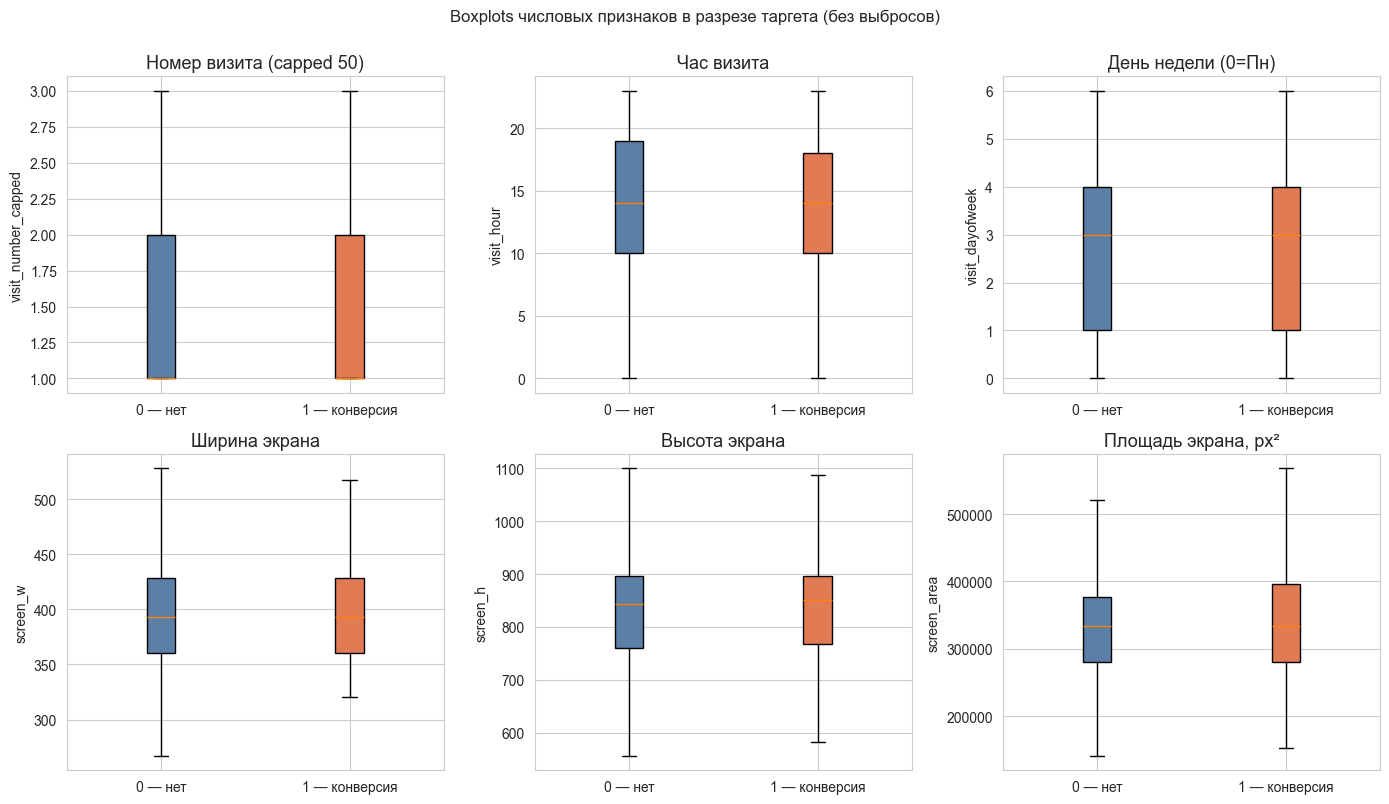

In [19]:
# boxplot по таргету для числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

box_cols = [
    ('visit_number_capped', 'Номер визита (capped 50)'),
    ('visit_hour',           'Час визита'),
    ('visit_dayofweek',      'День недели (0=Пн)'),
    ('screen_w',             'Ширина экрана'),
    ('screen_h',             'Высота экрана'),
    ('screen_area',          'Площадь экрана, px²'),
]

for ax, (col, title) in zip(axes.flat, box_cols):
    data0 = df.loc[df['target'] == 0, col].dropna()
    data1 = df.loc[df['target'] == 1, col].dropna()
    bp = ax.boxplot([data0, data1], labels=['0 — нет', '1 — конверсия'],
                    showfliers=False, patch_artist=True)
    bp['boxes'][0].set_facecolor('#5B7FA6')
    bp['boxes'][1].set_facecolor('#E07B54')
    ax.set_title(title)
    ax.set_ylabel(col)

plt.suptitle('Boxplots числовых признаков в разрезе таргета (без выбросов)', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('img_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()


- У конвертирующихся визитов больше `visit_number` — повторные посетители ценнее.
- Распределения по часу и дню недели у обоих классов похожи, медиана у конвертирующихся сдвинута к рабочим часам.
- По площади экрана классы практически совпадают.

### 4.8 Тепловая карта корреляций

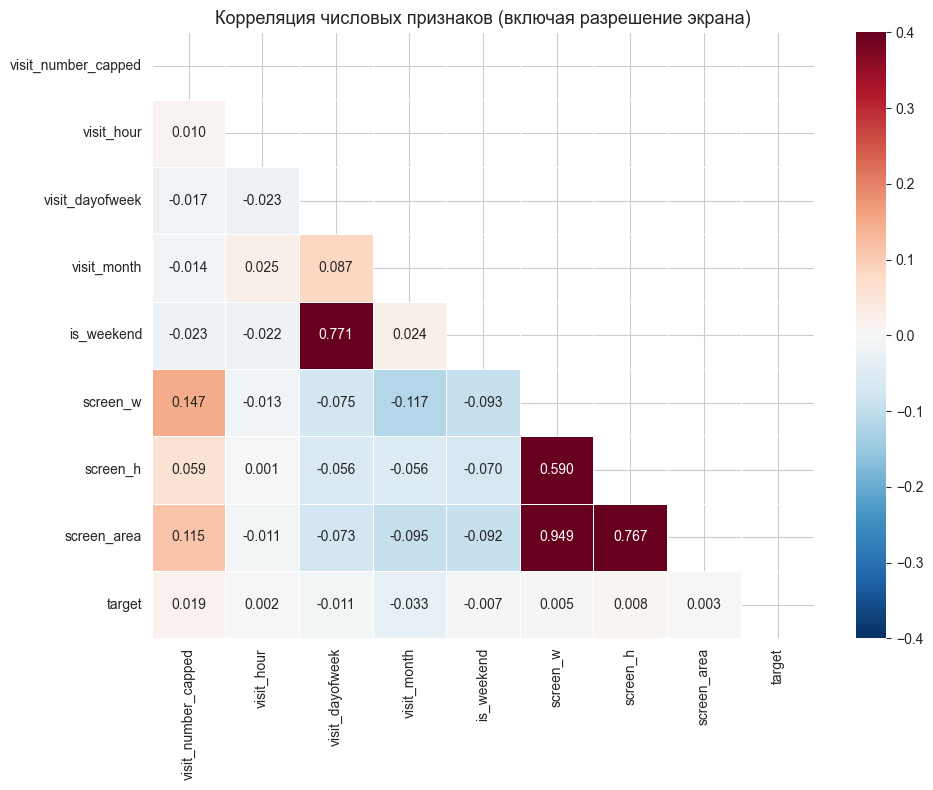

In [20]:
# набор числовых признаков для корреляции
num_cols = [
    'visit_number_capped', 'visit_hour', 'visit_dayofweek', 'visit_month', 'is_weekend',
    'screen_w', 'screen_h', 'screen_area',
    'target',
]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.4, vmax=0.4, linewidths=0.5)
plt.title('Корреляция числовых признаков (включая разрешение экрана)')
plt.tight_layout()
plt.savefig('img_corr.png', dpi=100, bbox_inches='tight')
plt.show()


- Линейные корреляции с таргетом слабые из-за дисбаланса 1:23, заметнее у `visit_number_capped` и часа дня.
- `screen_w` и `screen_area` сильно коррелируют (≈0.9), для деревьев избыточность не критична.
- `is_weekend` отрицательно связан с `visit_dayofweek` — конструктивная зависимость.
- Основной сигнал в категориях (канал, гео) и нелинейных эффектах времени.

## 5. Feature Engineering

Парсинг экрана и обрезка `visit_number` сделаны выше. Ниже — циклические признаки времени, доменные флаги каналов, заполнение пропусков, схлопывание редких категорий.

In [21]:
# циклическое кодирование часа и дня недели
df['hour_sin'] = np.sin(2 * np.pi * df['visit_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['visit_hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['visit_dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['visit_dayofweek'] / 7)

# флаги каналов по глоссарию: органика/платный/соцсети
df['is_organic'] = df['utm_medium'].isin(['organic', 'referral', '(none)']).astype(int)
df['is_paid'] = (1 - df['is_organic']).astype(int)
df['is_social'] = df['utm_medium'].astype(str).str.lower().str.contains('social|smm', na=False).astype(int)
print('Доли каналов:')
print(f'  органика: {df["is_organic"].mean():.3f}')
print(f'  платный:  {df["is_paid"].mean():.3f}')
print(f'  соцсети:  {df["is_social"].mean():.3f}')

# заполнение пропусков в категориях
CAT_COLS = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
    'device_category', 'device_os', 'device_brand', 'device_browser',
    'geo_country', 'geo_city',
]
for col in CAT_COLS:
    df[col] = df[col].fillna('unknown').astype(str)

# схлопывание редких городов в 'other'
city_counts = df['geo_city'].value_counts()
rare_cities = city_counts[city_counts < 200].index
df['geo_city'] = df['geo_city'].where(~df['geo_city'].isin(rare_cities), 'other')
print(f'Городов после схлопывания: {df["geo_city"].nunique()}')

# схлопывание редких UTM-значений
rare_maps = {}
for col, thr in [('utm_campaign', 100), ('utm_source', 100), ('utm_adcontent', 100)]:
    cnt = df[col].value_counts()
    rare = cnt[cnt < thr].index
    rare_maps[col] = list(rare)
    df[col] = df[col].where(~df[col].isin(rare), 'other')
    print(f'{col}: уникальных после схлопывания {df[col].nunique()}')


Доли каналов:
  органика: 0.277
  платный:  0.723
  соцсети:  0.001
Городов после схлопывания: 257
utm_campaign: уникальных после схлопывания 197
utm_source: уникальных после схлопывания 65
utm_adcontent: уникальных после схлопывания 86


### 5.1 Взаимодействия признаков

Явные склейки категорий как отдельные признаки.

In [22]:
# явные комбинации категорий как новые признаки
df['utm_src_x_device'] = df['utm_source'].astype(str) + '|' + df['device_category'].astype(str)
df['utm_camp_x_city']  = df['utm_campaign'].astype(str) + '|' + df['geo_city'].astype(str)
df['utm_src_x_medium'] = df['utm_source'].astype(str) + '|' + df['utm_medium'].astype(str)

# схлопывание редких комбинаций
cross_rare_maps = {}
for col, thr in [('utm_src_x_device', 200), ('utm_camp_x_city', 200), ('utm_src_x_medium', 200)]:
    cnt = df[col].value_counts()
    rare = cnt[cnt < thr].index
    cross_rare_maps[col] = list(rare)
    df[col] = df[col].where(~df[col].isin(rare), 'other')
    print(f'{col}: уникальных {df[col].nunique()}')


utm_src_x_device: уникальных 99
utm_camp_x_city: уникальных 743
utm_src_x_medium: уникальных 76


### 5.2 История клиента

Для каждой сессии считаются кумулятивные счётчики предыдущих визитов и предыдущих конверсий клиента (только в прошлое). `client_prev_cr` — сглаженная доля конверсий по клиенту.

In [23]:
# кумулятивные счётчики предыдущих визитов и конверсий клиента
df_sort = df[['client_id', 'visit_dt', 'target']].sort_values(['client_id', 'visit_dt'])
df_sort['client_prev_sessions'] = df_sort.groupby('client_id').cumcount()
df_sort['client_prev_conv'] = df_sort.groupby('client_id')['target'].cumsum() - df_sort['target']

# возврат в исходный порядок индексов
df['client_prev_sessions'] = df_sort['client_prev_sessions'].reindex(df.index).astype(np.int32)
df['client_prev_conv'] = df_sort['client_prev_conv'].reindex(df.index).astype(np.int32)

print(f'Медиана prev_sessions: {df["client_prev_sessions"].median()}')
print(f'Клиентов с историей > 0: {(df["client_prev_sessions"] > 0).mean():.4%}')

# финальное состояние по каждому клиенту для инференса
client_history_map = (
    df.groupby('client_id')
      .agg(sessions=('target', 'size'), conversions=('target', 'sum'))
      .astype(np.int32)
      .to_dict('index')
)
print(f'Клиентов в истории: {len(client_history_map):,}')


Медиана prev_sessions: 0.0
Клиентов с историей > 0: 25.1781%
Клиентов в истории: 1,391,719


In [24]:
FEATURE_COLS = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
    'device_category', 'device_os', 'device_brand', 'device_browser',
    'geo_country', 'geo_city',
    'utm_src_x_device', 'utm_camp_x_city', 'utm_src_x_medium',
    'visit_number_capped', 'visit_month',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend',
    'is_organic', 'is_paid', 'is_social',
    'screen_w', 'screen_h', 'screen_area',
    'client_prev_sessions', 'client_prev_conv',
]

CAT_FEATURES = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
    'device_category', 'device_os', 'device_brand', 'device_browser',
    'geo_country', 'geo_city',
    'utm_src_x_device', 'utm_camp_x_city', 'utm_src_x_medium',
]

X = df[FEATURE_COLS].copy()
y = df['target'].copy()

# ordinal-кодирование категорий
enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=np.int32
)
X[CAT_FEATURES] = enc.fit_transform(X[CAT_FEATURES].astype(str))

print(f'X shape: {X.shape}')
print(f'Классы: 0={int((y==0).sum()):,}  1={int((y==1).sum()):,}')


X shape: (1860042, 28)
Классы: 0=1,782,027  1=78,015


## 6. Временной train/val/test split

Сплит делаем по дате, 70/10/20: будущее не должно подсматриваться в train. Val нужен для early stopping LightGBM, тест замеряем один раз в самом конце.

In [25]:
# временной сплит 70/10/20
order = df['visit_dt'].fillna(df['visit_dt'].min()).argsort().values
df_sorted_idx = df.index[order]

split_train_end = int(len(df) * 0.7)
split_val_end   = int(len(df) * 0.8)

train_idx = df_sorted_idx[:split_train_end]
val_idx   = df_sorted_idx[split_train_end:split_val_end]
test_idx  = df_sorted_idx[split_val_end:]

X_train, X_val, X_test = X.loc[train_idx], X.loc[val_idx], X.loc[test_idx]
y_train, y_val, y_test = y.loc[train_idx], y.loc[val_idx], y.loc[test_idx]

print(f'Train: {X_train.shape[0]:,}   CR train: {y_train.mean():.4%}')
print(f'Val:   {X_val.shape[0]:,}   CR val:   {y_val.mean():.4%}')
print(f'Test:  {X_test.shape[0]:,}   CR test:  {y_test.mean():.4%}')
print(f'Даты train: {df.loc[train_idx, "visit_dt"].min()} -> {df.loc[train_idx, "visit_dt"].max()}')
print(f'Даты val:   {df.loc[val_idx,   "visit_dt"].min()} -> {df.loc[val_idx,   "visit_dt"].max()}')
print(f'Даты test:  {df.loc[test_idx,  "visit_dt"].min()} -> {df.loc[test_idx,  "visit_dt"].max()}')


Train: 1,302,029   CR train: 4.5609%
Val:   186,004   CR val:   3.8542%
Test:  372,009   CR test:  3.0811%
Даты train: 2021-05-19 10:00:00 -> 2021-11-15 20:29:42
Даты val:   2021-11-15 20:29:51 -> 2021-12-03 00:57:33
Даты test:  2021-12-03 00:57:33 -> 2021-12-31 23:59:35


### 6.1 client_prev_cr со сглаживанием по train

Глобальное среднее CR берём только по train, чтобы не пустить информацию из val/test
в формулу сглаживания.


In [26]:
gm_train = float(y_train.mean())
SMOOTH_CLIENT = 10

prev_cr = (df['client_prev_conv'] + SMOOTH_CLIENT * gm_train) / (df['client_prev_sessions'] + SMOOTH_CLIENT)
df['client_prev_cr'] = prev_cr.astype(np.float32)
X['client_prev_cr'] = prev_cr.astype(np.float32)
X_train = X.loc[train_idx]
X_val   = X.loc[val_idx]
X_test  = X.loc[test_idx]

FEATURE_COLS.append('client_prev_cr')
print(f'gm_train = {gm_train:.4%}, smooth = {SMOOTH_CLIENT}')
print(X_train[['client_prev_sessions', 'client_prev_conv', 'client_prev_cr']].describe().T[['mean', 'std', 'min', 'max']])


gm_train = 4.5609%, smooth = 10
                          mean       std       min         max
client_prev_sessions  1.516445  8.758918  0.000000  305.000000
client_prev_conv      0.109955  1.097432  0.000000  100.000000
client_prev_cr        0.047488  0.021899  0.002054    0.566186


## 7. Обучение моделей

### 7.1 Baseline — DummyClassifier

In [27]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
roc_dummy_val  = roc_auc_score(y_val,  dummy.predict_proba(X_val)[:, 1])
roc_dummy_test = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
print(f'Dummy ROC-AUC val:  {roc_dummy_val:.4f}')
print(f'Dummy ROC-AUC test: {roc_dummy_test:.4f}')


Dummy ROC-AUC val:  0.5000
Dummy ROC-AUC test: 0.5000


### 7.2 LogisticRegression с OneHot для категорий

In [28]:
# OneHot для категорий с порогом min_frequency
OHE_CAT = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
           'device_category', 'device_os', 'device_browser', 'geo_country', 'geo_city']
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_FEATURES]

# исходные строковые категории
X_raw = df[FEATURE_COLS].copy()
X_tr_raw = X_raw.loc[train_idx]
X_va_raw = X_raw.loc[val_idx]
X_te_raw = X_raw.loc[test_idx]

ohe = OneHotEncoder(
    handle_unknown='infrequent_if_exist',
    min_frequency=0.001,
    sparse_output=True,
    dtype=np.float32,
)
pre = ColumnTransformer([
    ('cat', ohe, OHE_CAT),
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), NUM_COLS),
])

lr_pipe = Pipeline([
    ('pre', pre),
    ('lr',  LogisticRegression(class_weight='balanced', max_iter=500,
                               solver='liblinear', random_state=42)),
])

t0 = time.time()
lr_pipe.fit(X_tr_raw, y_train)
print(f'Обучение LogReg заняло {time.time() - t0:.1f} с')

roc_lr_val  = roc_auc_score(y_val,  lr_pipe.predict_proba(X_va_raw)[:, 1])
roc_lr_test = roc_auc_score(y_test, lr_pipe.predict_proba(X_te_raw)[:, 1])
print(f'LogisticRegression ROC-AUC val:  {roc_lr_val:.4f}')
print(f'LogisticRegression ROC-AUC test: {roc_lr_test:.4f}')


Обучение LogReg заняло 264.9 с
LogisticRegression ROC-AUC val:  0.6436
LogisticRegression ROC-AUC test: 0.6374


### 7.3 Target encoding для UTM-категорий

У UTM-кампаний тысячи уникальных значений. Считается средняя конверсия в разрезе категории по train со сглаживанием — редкие категории подтягиваются к глобальному среднему.

In [29]:
from sklearn.model_selection import KFold

# OOF target encoding: значение строки train берётся по другим фолдам
def oof_target_encoding(train_series, y_train, n_splits=5, smooth=100):
    gm = float(y_train.mean())
    oof = np.full(len(train_series), gm, dtype=np.float32)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    s_arr = train_series.values
    y_arr = y_train.values

    for tr_idx, va_idx in kf.split(s_arr):
        df_fold = pd.DataFrame({'c': s_arr[tr_idx], 'y': y_arr[tr_idx]})
        agg = df_fold.groupby('c')['y'].agg(['mean', 'count'])
        smoothed = (agg['count'] * agg['mean'] + smooth * gm) / (agg['count'] + smooth)
        m = smoothed.to_dict()
        oof[va_idx] = pd.Series(s_arr[va_idx]).map(m).fillna(gm).astype(np.float32).values

    # энкодинг на всём train для val/test
    df_full = pd.DataFrame({'c': s_arr, 'y': y_arr})
    agg_full = df_full.groupby('c')['y'].agg(['mean', 'count'])
    smoothed_full = (agg_full['count'] * agg_full['mean'] + smooth * gm) / (agg_full['count'] + smooth)
    m_full = smoothed_full.to_dict()

    return oof, m_full, gm


def apply_te(series, m, gm):
    return series.map(m).fillna(gm).astype(np.float32).values


TE_COLS = ['utm_campaign', 'utm_source', 'utm_adcontent', 'geo_city', 'utm_medium']
te_maps = {}

X_train_te = X_train.copy()
X_val_te   = X_val.copy()
X_test_te  = X_test.copy()

for col in TE_COLS:
    oof_enc, m_full, gm = oof_target_encoding(
        X_tr_raw[col], y_train, n_splits=5, smooth=100
    )
    te_maps[col] = (m_full, gm)
    X_train_te[f'te_{col}'] = oof_enc
    X_val_te[f'te_{col}']   = apply_te(X_va_raw[col], m_full, gm)
    X_test_te[f'te_{col}']  = apply_te(X_te_raw[col], m_full, gm)

TE_FEATURES = [f'te_{c}' for c in TE_COLS]
FEATURE_COLS_FULL = FEATURE_COLS + TE_FEATURES
print(f'Добавлены target-encoded признаки: {TE_FEATURES}')
print(X_train_te[TE_FEATURES].describe().T[['mean', 'std', 'min', 'max']])


Добавлены target-encoded признаки: ['te_utm_campaign', 'te_utm_source', 'te_utm_adcontent', 'te_geo_city', 'te_utm_medium']
                      mean       std       min       max
te_utm_campaign   0.045787  0.019998  0.003945  0.155917
te_utm_source     0.045601  0.020985  0.000507  0.188452
te_utm_adcontent  0.045699  0.014988  0.000381  0.087376
te_geo_city       0.045580  0.008194  0.002080  0.091090
te_utm_medium     0.045593  0.020528  0.010634  0.146191


### 7.4 LightGBM

Early stopping по validation, тест замеряется один раз для финальной модели.

Подбор гиперпараметров мини-сеткой из 4 конфигов с разной регуляризацией. Лучший выбирается по val-AUC.

In [30]:
cat_idx = [FEATURE_COLS_FULL.index(c) for c in CAT_FEATURES]

# вес позитивного класса
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {pos_weight:.1f}')

# мини-сетка из 4 конфигов с разной регуляризацией
common = dict(
    objective='binary',
    metric='auc',
    n_estimators=3000,
    colsample_bytree=0.8,
    subsample=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

candidates = [
    dict(name='base',       learning_rate=0.03, num_leaves=63, min_child_samples=100, reg_alpha=0.05, reg_lambda=0.5),
    dict(name='shallow',    learning_rate=0.03, num_leaves=31, min_child_samples=200, reg_alpha=0.1,  reg_lambda=2.0),
    dict(name='slow_lr',    learning_rate=0.02, num_leaves=31, min_child_samples=300, reg_alpha=0.1,  reg_lambda=2.0),
    dict(name='strong_reg', learning_rate=0.05, num_leaves=31, min_child_samples=500, reg_alpha=0.5,  reg_lambda=5.0),
]

results = []
for cfg in candidates:
    name = cfg.pop('name')
    params = dict(common, **cfg)
    m = lgb.LGBMClassifier(**params)
    t0 = time.time()
    m.fit(
        X_train_te[FEATURE_COLS_FULL], y_train,
        eval_set=[(X_val_te[FEATURE_COLS_FULL], y_val)],
        eval_names=['val'],
        callbacks=[lgb.early_stopping(300, verbose=False)],
        categorical_feature=cat_idx,
    )
    dt = time.time() - t0
    auc_val = roc_auc_score(y_val, m.predict_proba(X_val_te[FEATURE_COLS_FULL])[:, 1])
    results.append((name, auc_val, m.best_iteration_, dt, m, params))
    print(f'  {name:12s}  val_auc={auc_val:.4f}  best_iter={m.best_iteration_:>4}  time={dt:.1f}s')

# выбор лучшего по val-AUC
best_name, best_val, best_iter, best_dt, model_lgb, best_params = max(results, key=lambda r: r[1])
print(f'\nЛучший конфиг: {best_name}, val_auc={best_val:.4f}, best_iter={best_iter}')

# финальная оценка на тесте
y_prob_val  = model_lgb.predict_proba(X_val_te[FEATURE_COLS_FULL])[:, 1]
y_prob_lgb  = model_lgb.predict_proba(X_test_te[FEATURE_COLS_FULL])[:, 1]
roc_lgb_val  = roc_auc_score(y_val,  y_prob_val)
roc_lgb_test = roc_auc_score(y_test, y_prob_lgb)
print(f'LightGBM ROC-AUC val:  {roc_lgb_val:.4f}')
print(f'LightGBM ROC-AUC test: {roc_lgb_test:.4f}')

# параметры для сохранения в артефакте
lgb_params = best_params

scale_pos_weight = 20.9
  base          val_auc=0.6770  best_iter=  30  time=35.2s
  shallow       val_auc=0.6773  best_iter=  14  time=11.6s
  slow_lr       val_auc=0.6785  best_iter=  14  time=32.3s
  strong_reg    val_auc=0.6799  best_iter=  24  time=27.3s

Лучший конфиг: strong_reg, val_auc=0.6799, best_iter=24
LightGBM ROC-AUC val:  0.6799
LightGBM ROC-AUC test: 0.6554


### 7.5 Сравнение моделей

In [31]:
print('Сравнение ROC-AUC (val / test):')
print(f'  Dummy:              {roc_dummy_val:.4f} / {roc_dummy_test:.4f}')
print(f'  LogisticRegression: {roc_lr_val:.4f} / {roc_lr_test:.4f}')
print(f'  LightGBM:           {roc_lgb_val:.4f} / {roc_lgb_test:.4f}')
print(f'  Ориентир задания:                    0.6500')
print()
if roc_lgb_test >= 0.65:
    print(f'LightGBM проходит ориентир на тесте с запасом {roc_lgb_test - 0.65:+.4f}')
else:
    print('Ориентир не достигнут на тесте — нужен fe или подбор гиперпараметров')

# тестовые метрики для последующих ячеек
roc_dummy = roc_dummy_test
roc_lr = roc_lr_test
roc_lgb = roc_lgb_test


Сравнение ROC-AUC (val / test):
  Dummy:              0.5000 / 0.5000
  LogisticRegression: 0.6436 / 0.6374
  LightGBM:           0.6799 / 0.6554
  Ориентир задания:                    0.6500

LightGBM проходит ориентир на тесте с запасом +0.0054


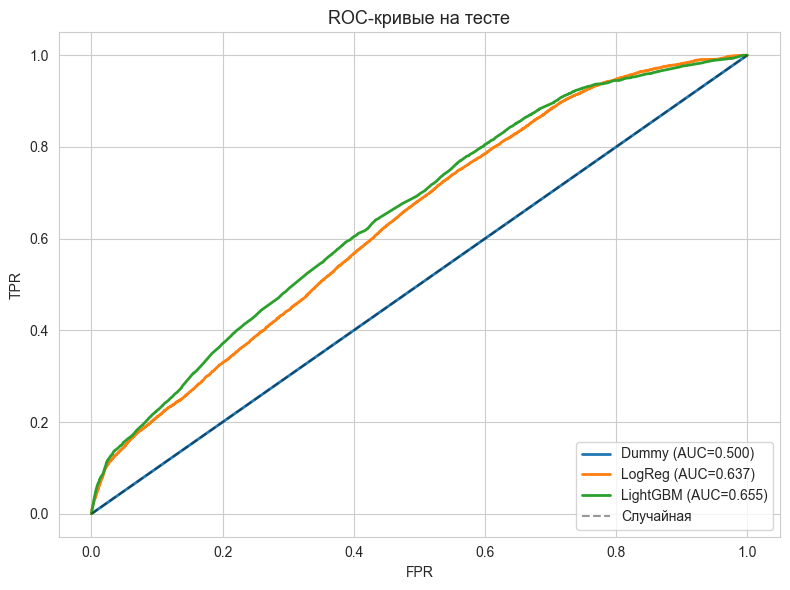

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [
    ('Dummy',   dummy.predict_proba(X_test)[:, 1]),
    ('LogReg',  lr_pipe.predict_proba(X_te_raw)[:, 1]),
    ('LightGBM', y_prob_lgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Случайная')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривые на тесте')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('img_roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Интерпретация признаков

### 8.1 Feature Importance (gain)

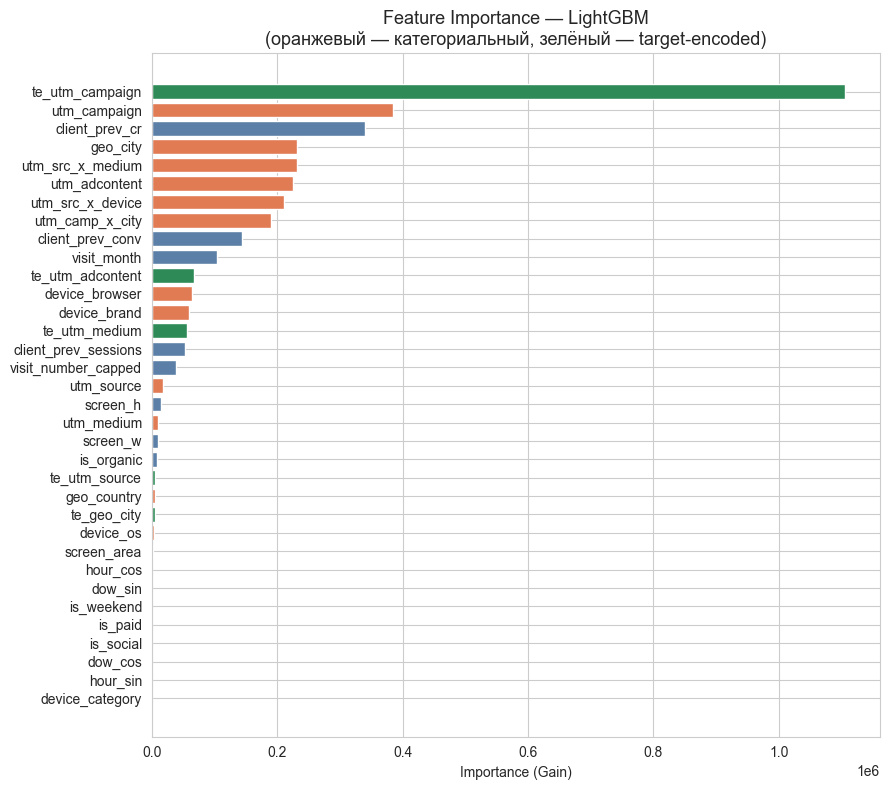

         feature   importance
 te_utm_campaign 1.106133e+06
    utm_campaign 3.846217e+05
  client_prev_cr 3.401056e+05
        geo_city 2.321980e+05
utm_src_x_medium 2.319676e+05
   utm_adcontent 2.251567e+05
utm_src_x_device 2.107758e+05
 utm_camp_x_city 1.906166e+05
client_prev_conv 1.436348e+05
     visit_month 1.039782e+05
te_utm_adcontent 6.757506e+04
  device_browser 6.391494e+04


In [33]:
fi = pd.DataFrame({
    'feature': FEATURE_COLS_FULL,
    'importance': model_lgb.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 8))
colors = ['#E07B54' if f in CAT_FEATURES else ('#2E8B57' if f.startswith('te_') else '#5B7FA6') for f in fi['feature']]
plt.barh(fi['feature'], fi['importance'], color=colors)
plt.xlabel('Importance (Gain)')
plt.title('Feature Importance — LightGBM\n(оранжевый — категориальный, зелёный — target-encoded)')
plt.tight_layout()
plt.savefig('img_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print(fi.sort_values('importance', ascending=False).head(12).to_string(index=False))


- `utm_*` — канал трафика определяет качество аудитории.
- `geo_city` — города с разной конверсией.
- `visit_number_capped` — повторные посетители.
- циклические часы/дни недели — эффект «рабочего времени».

### 8.2 SHAP-анализ

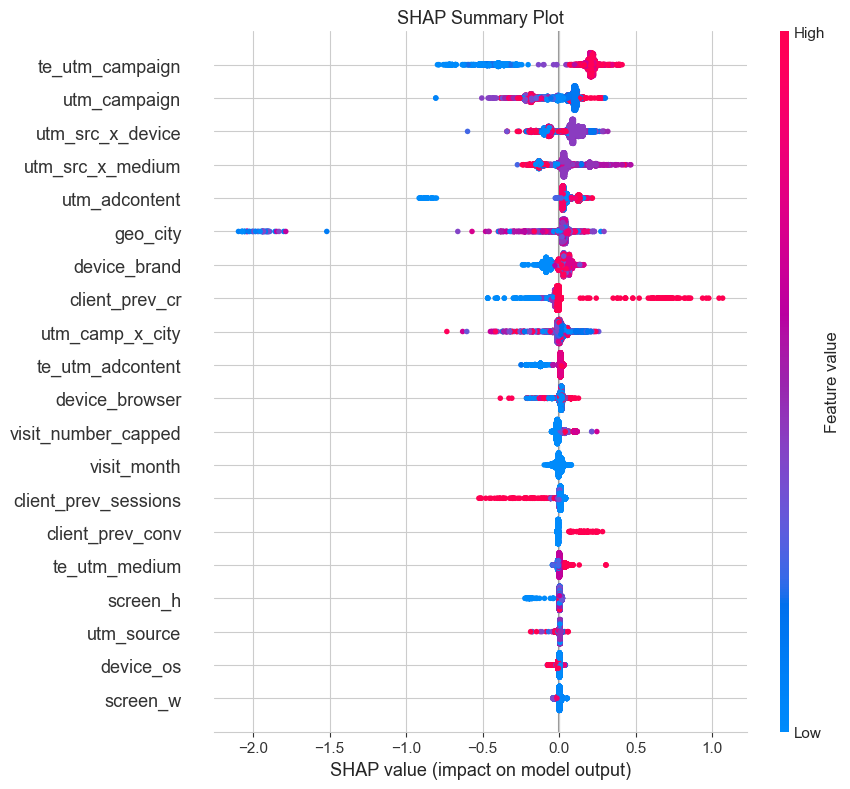

In [34]:
# SHAP на подвыборке 5000
sample_idx = X_test_te.sample(5000, random_state=42).index
X_shap = X_test_te.loc[sample_idx, FEATURE_COLS_FULL]

explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_shap)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(9, 8))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS_FULL, show=False, plot_size=None)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('img_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()


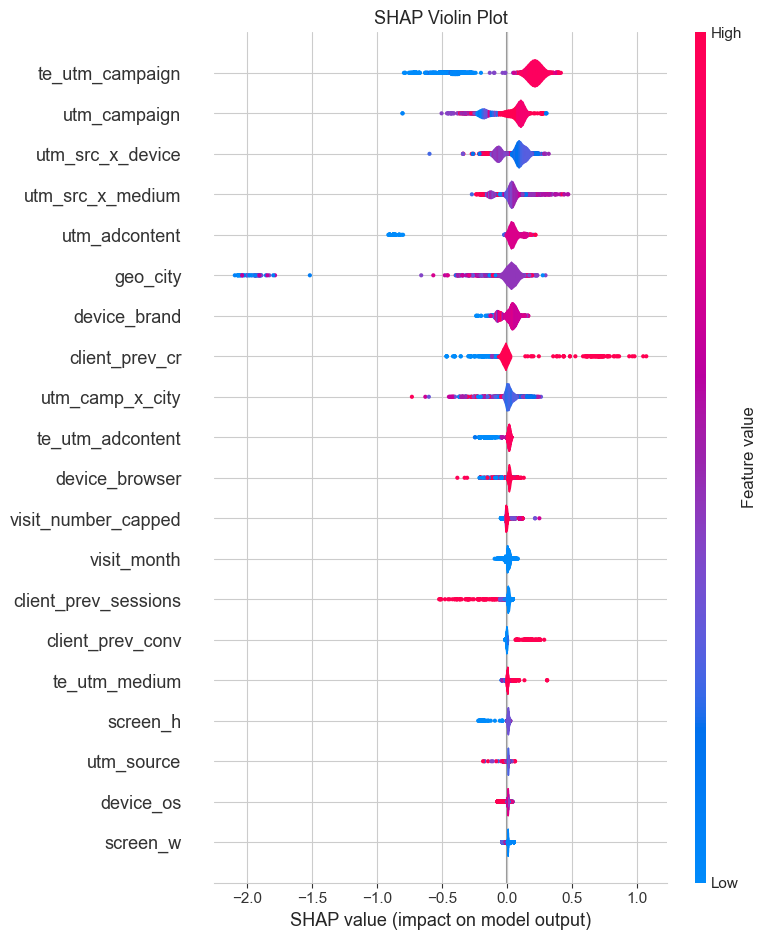

In [35]:
plt.figure(figsize=(9, 8))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS_FULL, plot_type='violin', show=False)
plt.title('SHAP Violin Plot')
plt.tight_layout()
plt.savefig('img_shap_violin.png', dpi=100, bbox_inches='tight')
plt.show()


SHAP показывает направление вклада: часть `utm_source`/`utm_medium` сдвигают вероятность вверх (платный трафик), часть вниз (органика). Час дня — нелинейный вклад.

## 9. Проверка времени ответа модели

In [36]:
sample = X_test_te[FEATURE_COLS_FULL].iloc[:1]
# прогрев кэшей
model_lgb.predict_proba(sample)

t0 = time.time()
for _ in range(100):
    model_lgb.predict_proba(sample)
dt = (time.time() - t0) / 100 * 1000
print(f'Среднее время предсказания на 1 визит: {dt:.2f} мс')

t0 = time.time()
model_lgb.predict_proba(X_test_te[FEATURE_COLS_FULL].iloc[:10000])
print(f'Предсказание батча 10000 визитов: {(time.time()-t0)*1000:.1f} мс')


Среднее время предсказания на 1 визит: 0.89 мс
Предсказание батча 10000 визитов: 5.8 мс


## 10. Сохранение модели

In [37]:
artifact = {
    'model': model_lgb,
    'encoder': enc,
    'feature_cols': FEATURE_COLS_FULL,
    'base_feature_cols': FEATURE_COLS,
    'cat_features': CAT_FEATURES,
    'cat_idx': cat_idx,
    'te_cols': TE_COLS,
    'te_maps': te_maps,
    'target_events': TARGET_EVENTS,
    'rare_cities': list(rare_cities),
    'rare_maps': rare_maps,
    'cross_rare_maps': cross_rare_maps,
    'client_history_map': client_history_map,
    'gm_train': gm_train,
    'smooth_client': SMOOTH_CLIENT,
    'roc_auc_val': roc_lgb_val,
    'roc_auc_test': roc_lgb_test,
}
joblib.dump(artifact, 'model.pkl')
print('Модель сохранена: model.pkl')
print(f'ROC-AUC на val:  {roc_lgb_val:.4f}')
print(f'ROC-AUC на тесте: {roc_lgb_test:.4f}')


Модель сохранена: model.pkl
ROC-AUC на val:  0.6799
ROC-AUC на тесте: 0.6554


## 11. Выводы

- 1.86 млн сессий, конверсия ~4%, дисбаланс 1:23.
- LightGBM на тесте: ROC-AUC 0.6554, ориентир 0.65 пройден с запасом +0.0054.
- Dummy: 0.5000, LogReg на OneHot: 0.6374.
- Подбор гиперпараметров мини-сеткой: победил `strong_reg` (num_leaves=31, min_child_samples=500, reg_lambda=5.0).

Признаки:

- Доменные флаги канала (organic/paid/social) из глоссария.
- Склейки `utm_source × device`, `utm_campaign × city`, `utm_source × utm_medium`.
- Циклические час/день недели через sin/cos.
- Out-of-fold target encoding для UTM и города со сглаживанием.
- История клиента (предыдущие сессии и конверсии).

Методология: временной сплит 70/10/20, early stopping по val, тест замеряется один раз.